# Deep Reinforcement Learning — Lab Assignment 1

**Team 151 · Multi-Armed Bandit (MAB)**

| Name | Email |
|------|-------|
| Abhinav Mandloi | 2025aa05473@wilp.bits-pilani.ac.in |
| Prajwal Rastogi | 2025aa05564@wilp.bits-pilani.ac.in |
| Pritish Joshi | 2025aa05686@wilp.bits-pilani.ac.in |
| Satwinder Singh | 2025aa05553@wilp.bits-pilani.ac.in |
| Shray Vijay | 2025aa05533@wilp.bits-pilani.ac.in |


In [1]:
from datetime import datetime
import socket

print(f"Execution timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Virtual Machine ID : {socket.gethostname()}")

Execution timestamp: 2026-06-07 14:05:14
Virtual Machine ID : MacBookPro


In [2]:
#Imports
import random
import numpy as np
import pandas as pd

In [3]:
# Constants
GROUP_NUMBER = 151
N_PATIENTS = 1000

In [4]:
# Helper methods

def create_patient_dataset(n_patients: int = N_PATIENTS) -> pd.DataFrame:
    """Creating the patient dataset with patient_id and severity_score."""
    patient_ids = np.arange(n_patients)
    severity_scores = (patient_ids % 5) + 1
    return pd.DataFrame({
        "patient_id": patient_ids,
        "severity_score": severity_scores,
    })

## Task 1: Dataset Design

In [5]:
# seeding both RNGs with the group number so the run is repeatable
random.seed(GROUP_NUMBER)
np.random.seed(GROUP_NUMBER)


K = (GROUP_NUMBER % 3) + 5

hidden_success_probabilities = np.array([
    0.4 + ((GROUP_NUMBER + medicine_id) % 6) * 0.07
    for medicine_id in range(K)
])

medicine_summary = pd.DataFrame({
    "Medicine Id": np.arange(K),
    "Hidden Success Probability": hidden_success_probabilities,
})

patients = create_patient_dataset()

print(f"Group number (G): {GROUP_NUMBER}")
print(f"Total medicines (K): {K}")
display(medicine_summary)
display(patients.head(10))

Group number (G): 151
Total medicines (K): 6


,Medicine Id,Hidden Success Probability
0,0,0.47
1,1,0.54
2,2,0.61
3,3,0.68
4,4,0.75
5,5,0.40


,patient_id,severity_score
0,0,1
1,1,2
2,2,3
3,3,4
4,4,5
5,5,1
6,6,2
7,7,3
8,8,4
9,9,5


## Task 2: Immediate Exploitation Strategy

In [ ]:
def immediate_exploitation(patients, probs, k, trials=10):
    """Try each medicine 10 times, then stick with whichever looked best."""
    counts = np.zeros(k)
    successes = np.zeros(k)
    best = None                 # set once after the trial phase
    assigned, outcomes, utilities = [], [], []

    for pid, severity in zip(patients["patient_id"], patients["severity_score"]):
        if pid < k * trials:        # trial phase: each medicine 10 times, in order
            medicine = pid // trials
        else:
            if best is None:        # commit to current best, then constant
                best = int(np.argmax(successes / counts))
            medicine = best

        outcome = int(np.random.random() < probs[medicine])   
        utility = outcome * (1 - severity / 10)

        counts[medicine] += 1
        successes[medicine] += outcome
        assigned.append(medicine)
        outcomes.append(outcome)
        utilities.append(utility)

    patients["assigned_medicine"] = assigned
    patients["clinical_outcome"] = outcomes
    patients["utility_score"] = utilities
    return best, float(np.sum(utilities))

In [ ]:
# fresh copy of the Task 1 data to have reproducible run
data = patients.copy()

np.random.seed(GROUP_NUMBER)
random.seed(GROUP_NUMBER)
best, total_reward = immediate_exploitation(data, hidden_success_probabilities, K)

print(f"Committed medicine: {best}")
print(f"Cumulative reward: {total_reward:.2f}")
data.head(10)

Committed medicine: 3
Cumulative reward: 466.60


,patient_id,severity_score,assigned_medicine,clinical_outcome,utility_score
0,0,1,0,0,0.0
1,1,2,0,1,0.8
2,2,3,0,1,0.7
3,3,4,0,0,0.0
4,4,5,0,0,0.0
5,5,1,0,0,0.0
6,6,2,0,0,0.0
7,7,3,0,0,0.0
8,8,4,0,1,0.6
9,9,5,0,0,0.0


## Task 3: Controlled Clinical Trial Strategy (epsilon-greedy)

In [8]:
def epsilon_greedy(patients, probs, k, epsilon):
    """Usually go with the current best medicine, but now and then try a random one."""
    counts = np.zeros(k)
    successes = np.zeros(k)
    assigned, outcomes, utilities = [], [], []

    for severity in patients["severity_score"]:
        if np.random.random() < epsilon:
            medicine = np.random.randint(k)          # explore
        else:
            # exploit: argmax success rate; maximum(counts, 1) avoids /0
            medicine = int(np.argmax(successes / np.maximum(counts, 1)))

        outcome = int(np.random.random() < probs[medicine])
        utility = outcome * (1 - severity / 10)

        counts[medicine] += 1
        successes[medicine] += outcome
        assigned.append(medicine)
        outcomes.append(outcome)
        utilities.append(utility)

    patients["assigned_medicine"] = assigned
    patients["clinical_outcome"] = outcomes
    patients["utility_score"] = utilities
    return int(np.argmax(successes / np.maximum(counts, 1))), float(np.sum(utilities))

In [ ]:
# Run the strategy at 10% exploration, plus 1% and 50% for the analysis.
results = []
populated = {}
for epsilon in [0.01, 0.10, 0.50]:
    data = patients.copy()
    np.random.seed(GROUP_NUMBER)
    random.seed(GROUP_NUMBER)
    best, reward = epsilon_greedy(data, hidden_success_probabilities, K, epsilon)
    populated[epsilon] = data
    results.append({
        "exploration": f"{int(epsilon * 100)}%",
        "best_medicine": best,
        "cumulative_reward": round(reward, 2),
    })

display(pd.DataFrame(results))

print("Dynamically populated dataset (10% exploration run):")
populated[0.10].head(10)

,exploration,best_medicine,cumulative_reward
0,1%,4,485.3
1,10%,4,503.5
2,50%,4,474.8


Dynamically populated dataset (10% exploration run):


,patient_id,severity_score,assigned_medicine,clinical_outcome,utility_score
0,0,1,0,1,0.9
1,1,2,0,0,0.0
2,2,3,0,0,0.0
3,3,4,0,0,0.0
4,4,5,0,0,0.0
5,5,1,0,0,0.0
6,6,2,0,1,0.8
7,7,3,0,0,0.0
8,8,4,3,1,0.6
9,9,5,3,1,0.5


**Effect of the exploration rate**

All three settings eventually identify medicine 4 (the true best), but the amount of exploration controls the reward. At 10% the strategy earns the most (503.50): it locks onto the best medicine quickly and only occasionally tries others. At 1% it explores too rarely, so it is slow to discover medicine 4 and wastes early patients on a weaker arm before luck finds it (485.30). At 50% it keeps testing inferior medicines even after the best is known, giving about half the patients sub-optimal treatment (474.80). So a small but non-zero exploration rate works best.

## Task 4: Confidence-Based Strategy (UCB1)

In [ ]:
def ucb1(patients, probs, k):
    """UCB1: go with the medicine scoring highest on success rate + a bonus that favours
    the ones we have not tried much yet."""
    counts = np.zeros(k)
    successes = np.zeros(k)
    assigned, outcomes, utilities = [], [], []

    for t, severity in enumerate(patients["severity_score"], start=1):
        if 0 in counts:
            medicine = int(np.argmin(counts))            # one pass: try each medicine once
        else:
            mean = successes / counts
            bonus = np.sqrt(2 * np.log(t) / counts)
            medicine = int(np.argmax(mean + bonus))

        outcome = int(np.random.random() < probs[medicine])
        utility = outcome * (1 - severity / 10)

        counts[medicine] += 1
        successes[medicine] += outcome
        assigned.append(medicine)
        outcomes.append(outcome)
        utilities.append(utility)

    patients["assigned_medicine"] = assigned
    patients["clinical_outcome"] = outcomes
    patients["utility_score"] = utilities
    return int(np.argmax(successes / counts)), float(np.sum(utilities))

In [11]:
# fresh copy of the Task 1 data so every strategy starts from the same inputs
data = patients.copy()

np.random.seed(GROUP_NUMBER)
random.seed(GROUP_NUMBER)
best, total_reward = ucb1(data, hidden_success_probabilities, K)

print(f"Best medicine: {best}")
print(f"Cumulative reward: {total_reward:.2f}")
data.head(10)

Best medicine: 4
Cumulative reward: 450.00


,patient_id,severity_score,assigned_medicine,clinical_outcome,utility_score
0,0,1,0,0,0.0
1,1,2,1,1,0.8
2,2,3,2,1,0.7
3,3,4,3,0,0.0
4,4,5,4,1,0.5
5,5,1,5,0,0.0
6,6,2,1,0,0.0
7,7,3,2,0,0.0
8,8,4,4,1,0.6
9,9,5,4,1,0.5


## Task 5: Comparative Analysis

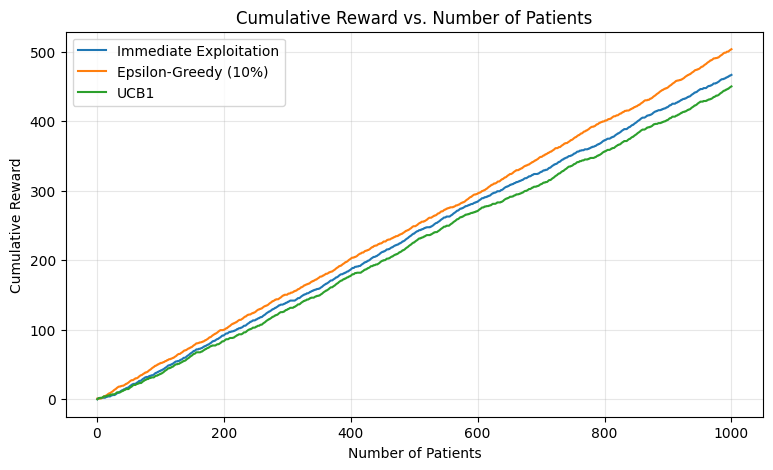

,strategy,final_reward,converged_after_n_patients,reward_stability_std
0,Immediate Exploitation,466.6,never,0.0447
1,Epsilon-Greedy (10%),503.5,69,0.0389
2,UCB1,450.0,never,0.0588


In [ ]:
import matplotlib.pyplot as plt

TRUE_BEST = int(np.argmax(hidden_success_probabilities))   # highest hidden probability medicine

def run_strategy(run):
    # run one strategy on a fresh copy, same seed, return the populated df
    data = patients.copy()
    np.random.seed(GROUP_NUMBER)
    random.seed(GROUP_NUMBER)
    run(data)
    return data

runs = {
    "Immediate Exploitation": lambda d: immediate_exploitation(d, hidden_success_probabilities, K),
    "Epsilon-Greedy (10%)": lambda d: epsilon_greedy(d, hidden_success_probabilities, K, 0.10),
    "UCB1": lambda d: ucb1(d, hidden_success_probabilities, K),
}
runs_data = {name: run_strategy(fn) for name, fn in runs.items()}

# cumulative reward vs number of patients
plt.figure(figsize=(9, 5))
for name, data in runs_data.items():
    plt.plot(data["patient_id"] + 1, data["utility_score"].cumsum(), label=name)
plt.xlabel("Number of Patients")
plt.ylabel("Cumulative Reward")
plt.title("Cumulative Reward vs. Number of Patients")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# metrics for the Q&A below
rows = []
for name, data in runs_data.items():
    on_best = (data["assigned_medicine"] == TRUE_BEST).rolling(50).mean()   # rolling-50 fraction on true best
    converged = on_best[on_best >= 0.9].index.min()                         # first index crossing 0.9
    rows.append({
        "strategy": name,
        "final_reward": round(data["utility_score"].sum(), 2),
        "converged_after_n_patients": "never" if pd.isna(converged) else int(converged) + 1,   # +1: 1-based, matches x-axis
        "reward_stability_std": round(data["utility_score"].rolling(50).mean().std(), 4),       # std of rolling mean (lower = steadier)
    })
pd.DataFrame(rows)

### Per-iteration progress (checkpoints every 200 patients)

The table below checks in every 200 patients and shows each strategy's cumulative reward so far, along with the medicine it picked most often in that window. It reuses the per-patient logs from above, so the numbers match the graph and the comparison table. Epsilon-Greedy and UCB1 settle on medicine 4 (the true best) early on, while Immediate Exploitation stays stuck on medicine 3.

In [13]:
# every 200 patients: cumulative reward so far + each strategy's most common pick in that block.
# reuses runs_data (nothing re-run), so the numbers match the graph/table above.
checkpoints = [200, 400, 600, 800, 1000]
progress = []
for name, data in runs_data.items():
    for n in checkpoints:
        window = data.iloc[n - 200:n]                       # last 200 patients
        favourite = int(window["assigned_medicine"].mode().iloc[0])   # modal pick in the window
        progress.append({
            "patients_seen": n,
            "strategy": name,
            "preferred_medicine_recent": favourite,
            "cumulative_reward": round(data["utility_score"].iloc[:n].sum(), 2),
        })

progress_df = pd.DataFrame(progress)

# pivot: one column per strategy
print("Running cumulative reward at each checkpoint:")
display(progress_df.pivot(index="patients_seen", columns="strategy", values="cumulative_reward"))

print("\nPreferred medicine over the preceding 200 patients (true best = medicine 4):")
display(progress_df.pivot(index="patients_seen", columns="strategy", values="preferred_medicine_recent"))

Running cumulative reward at each checkpoint:


strategy,Epsilon-Greedy (10%),Immediate Exploitation,UCB1
patients_seen,,,
200,99.9,91.6,83.3
400,201.9,186.4,177.4
600,295.7,284.0,270.6
800,400.1,372.1,356.0
1000,503.5,466.6,450.0



Preferred medicine over the preceding 200 patients (true best = medicine 4):


strategy,Epsilon-Greedy (10%),Immediate Exploitation,UCB1
patients_seen,,,
200,4,3,4
400,4,3,4
600,4,3,4
800,4,3,4
1000,4,3,4


**Comparison and answers**

The graph plots cumulative reward against the number of patients for the three strategies, all run on the same patient stream.

1. **Highest cumulative reward at 1000 patients:** Epsilon-Greedy (10%), with 503.5, ahead of Immediate Exploitation (466.6) and UCB1 (450.0).
2. **Identifies the best medicine fastest:** Epsilon-Greedy (10%). Its assignments settle on medicine 4 (the true best) after about 69 patients. Immediate Exploitation commits even earlier, after the first 60 patients, but to the wrong medicine 3, and UCB1 keeps re-testing the close second-best medicine 3. So neither of those two reliably locks onto the true best.
3. **Most stable (least fluctuation):** Epsilon-Greedy (10%), with the smallest variation in rolling-average reward (std 0.039). UCB1 fluctuates the most (0.059) because it never stops probing alternatives.
4. **Safest for real-world hospital deployment:** UCB1. Even though it earned less reward here, it never commits permanently based on a handful of samples (Immediate Exploitation got stuck on the wrong drug). Its exploration shrinks on its own as evidence builds up, instead of randomly treating a fixed 10% of patients forever, and it needs no hand-tuned exploration rate. That self-correcting behaviour, and the fact that it keeps regret low without any tuning, matters more than peak reward when patient safety is on the line.

**Summary:** Over 1000 patients, Epsilon-Greedy (10%) came out on top on every measure we looked at: highest reward, fastest convergence to medicine 4, and the smoothest curve. A small constant exploration rate finds the best treatment quickly and then mostly sticks with it. Immediate Exploitation is the riskiest of the three. It commits after only 10 trials each, locked onto medicine 3, and never recovered, which is a good illustration of why pure exploitation is dangerous. UCB1 avoids that trap and explores in a more measured, self-correcting way, but over this short horizon it spends too long confirming that the close second-best medicine 3 isn't actually better, and that costs it some reward. So for raw performance Epsilon-Greedy is the clear winner, while for a safety-first hospital rollout UCB1 is the more defensible choice.